In [1]:
import sys

sys.path.append("..")
from qiskit.quantum_info import SparsePauliOp
from qiskit import QuantumCircuit
from qiskit.circuit.library import PauliEvolutionGate
from qiskit_ibm_runtime import QiskitRuntimeService
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from numbers import Number
from qiskit.synthesis import LieTrotter
import numpy as np
import scipy as scipy
import matplotlib.pyplot as plt

### State preparation with 1 ancilla and 2 excitations on a total of 35 qubits

In [2]:
def prep_psi_0(qc: QuantumCircuit):
    qc.cx(34, 4)
    qc.cx(34, 21)
    return qc


def prep_psi_0_by_0(qc: QuantumCircuit):
    qc.cx(34, 4, ctrl_state="0")
    qc.cx(34, 21, ctrl_state="0")
    return qc

### Test if state prep works as expected

In [3]:
from qiskit_aer import StatevectorSimulator
from qiskit_aer.primitives import SamplerV2

#sv = StatevectorSimulator()
sampler=SamplerV2(options={"backend_options": {"method": "matrix_product_state"}})
qc = QuantumCircuit(35)
qc.h(34)
qc = prep_psi_0(qc)
qc.measure_all()

job = sampler.run([qc])
res = job.result()

res[0].data.meas.get_counts()

{'00000000000000000000000000000000000': 512,
 '10000000000001000000000000000010000': 512}

In [4]:
qc = QuantumCircuit(35)
qc.h(34)
qc = prep_psi_0(qc)
qc = prep_psi_0_by_0(qc)
qc.measure_all()
job = sampler.run([qc])
res = job.result()

res[0].data.meas.get_counts()

{'00000000000001000000000000000010000': 531,
 '10000000000001000000000000000010000': 493}

## Hardware experiments

In [7]:
from qiskit.transpiler import generate_preset_pass_manager
from qiskit_ibm_runtime import QiskitRuntimeService
service = QiskitRuntimeService(instance='ibm-q-qida/ibm/main',channel='ibm_quantum')
backend=service.backend('ibm_torino')

t_steps = 8
num_qubits = 34
circuits = np.ndarray([t_steps, t_steps], dtype=QuantumCircuit)
H_tilde = np.zeros([t_steps, t_steps], dtype=complex)
S_tilde = np.zeros([t_steps, t_steps], dtype=complex)
delta_t = np.pi / 40
synth = LieTrotter(reps=1)

qubit_subset = list(range(42, 48)) +[35]+ list(range(25, 30)) + [36,48,49,50,54] + list(range(61,66)) + list(range(66,70)) + [56,73,82,83,84,85,86,74] 
#remap = {q: i for q, i in zip(qubit_subset, range(len(qubit_subset)))}
#rev_map = {val: key for key, val in remap.items()}


cm = backend.coupling_map
reduced_map = cm.reduce(qubit_subset)
edge_list = {(a, b) if a < b else (b, a) for a, b in list(reduced_map.get_edges())}
#ent_dec = [(rev_map[i], rev_map[j]) for i, j in edge_list]


def Heisenberg(J, n, ent_map):
    if isinstance(J, Number):
        J = np.ones(len(ent_map)) * J
    else:
        assert len(J) == len(ent_map)
    String = "I" * n
    H = SparsePauliOp("I" * n, 0)
    for j, c in zip(J, ent_map):
        c = np.sort(c)
        XX = String[: c[0]] + "X" + String[c[0] + 1 : c[1]] + "X" + String[c[1] + 1 :]
        H += SparsePauliOp(XX, j)
        YY = String[: c[0]] + "Y" + String[c[0] + 1 : c[1]] + "Y" + String[c[1] + 1 :]
        H += SparsePauliOp(YY, j)
        ZZ = String[: c[0]] + "Z" + String[c[0] + 1 : c[1]] + "Z" + String[c[1] + 1 :]
        H += SparsePauliOp(ZZ, j)
    return H.chop()


H = Heisenberg(1, num_qubits, edge_list)

# Generate approximate time evolution, rather than using PauliEvolutionGate
Rxyz_circ = QuantumCircuit(2)
Rxyz_circ.rxx(2 * delta_t, 0, 1)
Rxyz_circ.ryy(2 * delta_t, 0, 1)
Rxyz_circ.rzz(2 * delta_t, 0, 1)
Rxyz_instr = Rxyz_circ.to_instruction(label="RXX+YY+ZZ")
qc_temp = QuantumCircuit(num_qubits)
for edge in edge_list:
    qc_temp.append(Rxyz_instr, edge)
time_evol = QuantumCircuit(num_qubits).compose(qc_temp)

#time_evol=PauliEvolutionGate(H,time=delta_t,synthesis=synth)
real_obs_H = SparsePauliOp("X", 1) ^ H
imag_obs_H = SparsePauliOp("Y", 1) ^ H
real_obs_S = SparsePauliOp("X", 1) ^ SparsePauliOp("I" * 34, 1)
imag_obs_S = SparsePauliOp("Y", 1) ^ SparsePauliOp("I" * 34, 1)


for j in range(t_steps):
    for i in range(j + 1):
        m = i
        n = j - i
        qc = QuantumCircuit(35)
        qc.h(34)
        qc = prep_psi_0(qc)
        for _ in range(n):
            qc.append(time_evol, range(34))
        qc = prep_psi_0_by_0(qc)
        for _ in range(m):
            qc.append(time_evol, range(34))
        circuits[i][j] = qc.copy()

init_layout = qubit_subset + [55]  # ancilla at qubit 55 on torino
pm = generate_preset_pass_manager(
    backend=backend, optimization_level=3, initial_layout=init_layout
)

circs = []
for i in range(t_steps):
    circs.append([])
    for j in range(t_steps):
        if circuits[i][j] is not None:
            circs[i].append(circuits[i][j])
        else:
            circs[i].append(circuits[j][i])

circs = [pm.run(circ) for circ in circs]

print(
    f"Max circuit depth:{max([circs[i][j].depth(lambda x: len(x.qubits)==2) for i in range(t_steps) for j in range(t_steps)])}"
)

IBMInputValueError: 'Hub/group/project ibm-q-qida/ibm/main could not be found for this account.'

# Circuit execution

## Run as individual jobs to allow more shots

In [66]:
from qiskit_ibm_runtime import EstimatorV2, Batch, EstimatorOptions

estimator = EstimatorV2(mode=backend)
estimator.options.default_shots = 800000  # Try going upto 1000000
estimator.options.resilience_level = 2
estimator.options.dynamical_decoupling.enable = True
estimator.options.dynamical_decoupling.sequence_type = "XY4"
estimator.options.resilience.zne.noise_factors = (1, 1.3, 1.6)  # use fractional folding
estimator.options.resilience.zne.extrapolator = (
    "linear"  # exponential fit showed high std's, use this instead.
)
estimator.options.experimental = {"execution_path": "gen3-turbo"}

est_jobs = []
for i in range(t_steps):
    for j in range(t_steps):
        if circuits[i][j] is not None:
            circ = circs[i][j]
        else:
            circ = circs[j][i]
        est_jobs.append(
            estimator.run(
                [
                    (
                        circ,
                        [
                            real_obs_H.apply_layout(circ.layout),
                            imag_obs_H.apply_layout(circ.layout),
                            real_obs_S.apply_layout(circ.layout),
                            imag_obs_S.apply_layout(circ.layout),
                        ],
                    )
                ]
            )
        )

In [1226]:
job_results = [job.result() for job in est_jobs]
print([job for job in jobs if job.errored()]) # check if any of the jobs errored.

[]


In [6]:
t_steps = 8
num_qubits = 34
H_tilde = np.zeros([t_steps, t_steps], dtype=complex)
S_tilde = np.zeros([t_steps, t_steps], dtype=complex)
idx = 0
for i in range(t_steps):
    for j in range(t_steps):
        if circuits[i][j] is not None:
            H_tilde[i, j] = (
                job_results[idx][0].data.evs[0] + 1j * job_results[idx][0].data.evs[1]
            )
            S_tilde[i, j] = (
                job_results[idx][0].data.evs[2] + 1j * job_results[idx][0].data.evs[3]
            )
        else:
            H_tilde[i, j] = np.conj(H_tilde[j, i])
            S_tilde[i, j] = np.conj(S_tilde[j, i])
        idx += 1

NameError: name 'circuits' is not defined

In [19]:
def truncation(threshold, S):
    eigvals, eigvecs = np.linalg.eig(S)
    idx = eigvals.argsort()[::-1]
    eigvals = eigvals[idx]
    eigvecs = eigvecs[:, idx]
    D = len(eigvals)
    truncated_eigvals = []
    truncated_eigvecs = []
    # make truncated matrix whose rows are eigenvectors of S with eigval above threshold
    for i in range(D):
        if eigvals[i] >= threshold:
            truncated_eigvals.append(eigvals[i])
            truncated_eigvecs.append(eigvecs[i])
    truncated_eigvals = np.array(truncated_eigvals)
    truncated_eigvecs = np.array(truncated_eigvecs).T
    print(len(truncated_eigvals))
    return truncated_eigvecs


def E_vs_D(H_tilde, S_tilde, threshold_slope):
    GSEs = []
    ground_states = []
    for d in range(1, len(S_tilde) + 1):
        epsilon = threshold_slope * d
        H_temp = H_tilde[0:d, 0:d]
        S_temp = S_tilde[0:d, 0:d]
        V_eps = truncation(epsilon, S_temp)
        # solve GEVP
        A = V_eps.conj().T @ H_temp @ V_eps
        B = V_eps.conj().T @ S_temp @ V_eps
        E, c = scipy.linalg.eig(a=A, b=B)
        idx = E.argsort()[::-1]
        eigvals = E[idx]
        eigvecs = c[:, idx]
        GSEs.append(eigvals[-1])
        ground_states.append(eigvecs[:, -1])
        #print(min(eigvals))

    return GSEs, ground_states, V_eps

## Run on simulator for comparison

In [21]:
from qiskit.transpiler import generate_preset_pass_manager
from qiskit.primitives import StatevectorEstimator
from qiskit_aer.primitives import EstimatorV2

from qiskit_aer.noise import  NoiseModel
backend = service.backend("ibm_torino")
noise_model = NoiseModel.from_backend(backend)



t_steps = 8
n_qubits = 34 #number of data qubits
circuits = np.ndarray([t_steps, t_steps], dtype=QuantumCircuit)
H_tilde_sim = np.zeros([t_steps, t_steps], dtype=complex)
S_tilde_sim = np.zeros([t_steps, t_steps], dtype=complex)
delta_t = np.pi / 40
synth = LieTrotter(reps=1)

H = Heisenberg(1, n_qubits, edge_list)

# Rxyz_circ = QuantumCircuit(2)
# Rxyz_circ.rxx(2 * delta_t, 0, 1)
# Rxyz_circ.ryy(2 * delta_t, 0, 1)
# Rxyz_circ.rzz(2 * delta_t, 0, 1)
# Rxyz_instr = Rxyz_circ.to_instruction(label="RXX+YY+ZZ")
# qc_temp = QuantumCircuit(n_qubits)
# for edge in edge_list:
#     qc_temp.append(Rxyz_instr, edge)
# time_evol = QuantumCircuit(n_qubits).compose(qc_temp)


time_evol=PauliEvolutionGate(H,time=delta_t,synthesis=synth)

real_obs_H = SparsePauliOp("X", 1) ^ H
imag_obs_H = SparsePauliOp("Y", 1) ^ H
real_obs_S = SparsePauliOp("X", 1) ^ SparsePauliOp("I" * n_qubits, 1)
imag_obs_S = SparsePauliOp("Y", 1) ^ SparsePauliOp("I" * n_qubits, 1)


for j in range(t_steps):
    for i in range(j + 1):
        m = i
        n = j - i
        qc = QuantumCircuit(35)
        qc.h(34)
        qc = prep_psi_0(qc)
        for _ in range(n):
            qc.append(time_evol, range(34))
        qc = prep_psi_0_by_0(qc)
        for _ in range(m):
            qc.append(time_evol, range(34))
        circuits[i][j] = qc.copy().decompose(reps=4)

simulator = EstimatorV2(options={"backend_options": {"method":"matrix_product_state"}})
for i in range(t_steps):
    for j in range(t_steps):
        if circuits[i][j] is not None:
            sim_job = simulator.run(
                [
                    (
                        circuits[i][j],
                        [real_obs_H, imag_obs_H, real_obs_S, imag_obs_S],
                    )
                ]
            )
            H_tilde_sim[i, j] = (
                sim_job.result()[0].data.evs[0] + 1j * sim_job.result()[0].data.evs[1]
            )
            S_tilde_sim[i, j] = (
                sim_job.result()[0].data.evs[2] + 1j * sim_job.result()[0].data.evs[3]
            )
        else:
            sim_job = simulator.run(
                [
                    (
                        circuits[j][i],
                        [real_obs_H, imag_obs_H, real_obs_S, imag_obs_S],
                    )
                ]
            )
            H_tilde_sim[i, j] = (
                sim_job.result()[0].data.evs[0] - 1j * sim_job.result()[0].data.evs[1]
            )
            S_tilde_sim[i, j] = (
                sim_job.result()[0].data.evs[2] - 1j * sim_job.result()[0].data.evs[3]
            )

In [22]:
Matrix(H_tilde_sim)

Matrix([
[           28.0 + 2.92849670134736e-30*I,     22.2941775765638 + 14.7254308399895*I,    9.20204908793286 + 21.1987188863426*I,    -2.74435906991105 + 17.7457591041692*I,    -7.8258358023051 + 9.50792365364058*I,    -6.64529519344027 + 2.80517745638234*I,  -3.37741853160159 + 0.0855517349036831*I,  -1.05157386037156 - 0.0488220419591266*I],
[   22.2941775765638 - 14.7254308399895*I, 28.0465201430759 - 1.52926876642488e-15*I,    22.3222576197176 + 14.7542604515019*I,     9.20015416198649 + 21.2285725731606*I,   -2.75978528868106 + 17.7556324458029*I,    -7.83292946467854 + 9.50196282479141*I,    -6.64001583220311 + 2.80044519335102*I,  -3.37090599829538 + 0.0891141546069496*I],
[   9.20204908793286 - 21.1987188863426*I,     22.3222576197176 - 14.7542604515019*I, 28.080453207401 + 1.23441832303698e-15*I,     22.3377640744402 + 14.7720089537593*I,    9.19607361185435 + 21.2400152526301*I,    -2.76493548719072 + 17.7511687966905*I,    -7.82583155498022 + 9.49324000164529*I,    -6.

In [23]:
Matrix(S_tilde_sim)

Matrix([
[              1.0 + 1.04589167905263e-31*I,     0.769905377186212 + 0.55936899906579*I,    0.25581727206519 + 0.776535145628038*I,  -0.183384610893827 + 0.600070848337293*I,  -0.328055091396683 + 0.263932853179582*I, -0.235343922306457 + 0.0274047219558672*I, -0.0952248050895814 - 0.0371352575511505*I, -0.0195575240706748 - 0.0161433690798013*I],
[    0.769905377186212 - 0.55936899906579*I,  1.00000000000005 - 5.55111512312603e-17*I,   0.769905377157796 + 0.559368999043725*I,    0.25581727206099 + 0.776535145635671*I,   -0.183384610893818 + 0.60007084832563*I,  -0.328055091400547 + 0.263932853180284*I,  -0.235343922352038 + 0.0274047219629674*I, -0.0952248050904551 - 0.0371352575457466*I],
[    0.25581727206519 - 0.776535145628038*I,    0.769905377157796 - 0.559368999043725*I, 1.00000000000009 + 4.39600569805527e-17*I,   0.769905377142986 + 0.559368999140411*I,    0.25581727190133 + 0.776535145654862*I,  -0.183384610848291 + 0.600070848387841*I,   -0.328055091433057 + 0.26393

1
2
3
4
5
6
7
8


/Users/ibrahimshehzad/uds/lib/python3.10/site-packages/matplotlib/cbook.py:1709: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/Users/ibrahimshehzad/uds/lib/python3.10/site-packages/matplotlib/cbook.py:1345: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


Text(0, 0.5, 'Ground state energy')

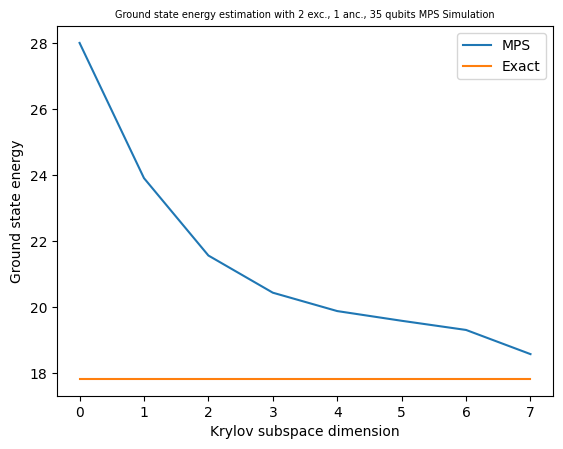

In [27]:
GSEs, _,_ = E_vs_D(H_tilde_sim, S_tilde_sim, 1e-11)
plt.plot(GSEs, label='MPS')  # Ground-state energies
plt.plot(17.81817798453781*np.ones(t_steps), label='Exact')
plt.title("Ground state energy estimation with 2 exc., 1 anc., 35 qubits MPS Simulation",fontsize=7)
plt.legend()
plt.xlabel("Krylov subspace dimension")
plt.ylabel("Ground state energy")

## Exact diagonalisation for comparison

In [1309]:
# Method from Krylov tutorial
import itertools as it
import scipy as sp
from qiskit.quantum_info import Pauli


def n_particle_gs(H_op, n_qubits, n_exc):
    """
    Find the ground state of the n particle(excitation) sector
    """
    H_x = []
    for p, coeff in H_op.to_list():
        H_x.append(set([i for i, v in enumerate(Pauli(p).x) if v]))

    H_z = []
    for p, coeff in H_op.to_list():
        H_z.append(set([i for i, v in enumerate(Pauli(p).z) if v]))

    H_c = H_op.coeffs

    n_exc = n_exc
    sub_dimn = int(sp.special.comb(n_qubits, n_exc))
    print("n_exc", n_exc, ", subspace dimension", sub_dimn)

    n_particle_H = np.zeros((sub_dimn, sub_dimn), dtype=complex)

    sparse_vecs = [
        set(vec) for vec in it.combinations(range(n_qubits), r=n_exc)
    ]  # list all of the possible sets of n_exc indices of 1s in n_exc-particle states
    for i, i_set in enumerate(sparse_vecs):
        for j, j_set in enumerate(sparse_vecs):
            if len(i_set.symmetric_difference(j_set)) <= 2:

                for p_x, p_z, coeff in zip(H_x, H_z, H_c):

                    if i_set.symmetric_difference(j_set) == p_x:
                        sgn = ((-1j) ** len(p_x.intersection(p_z))) * (
                            (-1) ** len(i_set.intersection(p_z))
                        )
                    else:
                        sgn = 0

                    n_particle_H[i, j] += sgn * coeff

    eige, eigv = np.linalg.eigh(n_particle_H)
    gs_en = eige[0]  # min(eige)
    gs_vec = eigv[:, 0]
    print("n_exc particle ground state energy: ", gs_en)
    return gs_en, gs_vec, n_particle_H


n_qubits = 34
edge_list = edge_list
H = Heisenberg(1, n_qubits, edge_list)
en, state, subspace_h = n_particle_gs(H, n_qubits, 2)
# print(np.linalg.norm(subspace_h,ord=2))

n_exc 2 , subspace dimension 561
n_exc particle ground state energy:  17.81817798453781
